# HALO — Marketing Assistant for Hairstylists
## Notebook 2: RAG Query Pipeline + Multi-Model API + Evaluation
**Course:** ITAI2377 | **Group:** Icarus Squad

**Team Members:** Oyinade Balogun · Francisco Medina Diaz · Rodrigo Sierra · Katherine Stanton

---

### About This Notebook
This notebook implements the core HALO backend pipeline:

1. Install dependencies and connect to the OpenCode Zen and Gemini APIs
2. Load the ChromaDB knowledge base built in Notebook 1
3. Retrieve the most relevant knowledge chunks for any user query
4. Generate grounded, beauty-specific responses via Multiple Models
5. Log all queries, retrievals, and responses for evaluation
6. Run 5 representative example interactions across different models
7. Run the 20-question evaluation suite and interactively score them
8. Save all logs and generate evaluation visualizations

### Notebook Structure
| Notebook | Purpose |
|---|---|
| **Notebook 1** | Data collection, preprocessing, chunking, ChromaDB storage |
| **Notebook 2** | RAG pipeline, API connections, evaluation framework (this notebook) |
| **Notebook 3** | Polished Gradio frontend interface |

### Prerequisites
- Notebook 1 must be fully executed and ChromaDB saved to Drive
- Add your `OPENCODE_API_KEY` and/or `GEMINI_API_KEY` to Colab Secrets (key icon in left sidebar)
- Each team member uses their own keys — no sharing required

### Google Drive Setup for Team Members
If this is your first time running this notebook:
1. Open Google Drive
2. Click **Shared with me** in the left sidebar
3. Right click **HALO_Project** → **Organize** → **Add shortcut to Drive**
4. Place the shortcut in **My Drive** root
5. The notebook will then find the shared folder automatically

---
## Step 1 — Install Dependencies

**Cell explanation:** This cell installs all Python libraries needed for this notebook.
Run this once at the start of every new Colab session. It does not need to be
re-run if you are continuing an existing session.

In [1]:
# Step 1: Install Dependencies
!pip install -q --upgrade google-generativeai chromadb sentence-transformers pandas==2.2.2 matplotlib seaborn tqdm openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 138.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 234.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 116.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 170.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 165.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.

---
## Step 2 — Imports & API Key Setup

**Cell explanation:** This cell imports all required libraries and loads your
API keys securely from Colab Secrets. The keys are never written into the
notebook code — they are read from your personal Colab Secrets panel which is
invisible to other team members and not stored in the shared notebook file.

We are primarily using **OpenCode Zen** to access various models (like GPT and Claude),
with **Gemini** available as a fallback or alternative.

**How to add your API keys:**
1. In Colab, click the 🔑 key icon in the left sidebar
2. Click **+ Add new secret**
3. Add your OpenCode Zen key (Name: `OPENCODE_API_KEY` | Value: paste your key)
4. Add your Google Gemini key (Name: `GEMINI_API_KEY` | Value: paste your key)
5. Toggle **Notebook access** to ON for both

In [2]:
# Step 2: Import Libraries and Configure Gemini API
import os
import csv
import time
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from IPython.display import display, Markdown

import chromadb
from sentence_transformers import SentenceTransformer
import google.generativeai as genai
from google.colab import userdata
from openai import OpenAI

# Load Gemini API key securely from Colab Secrets
# Get a free key at aistudio.google.com using your Google account
# No credit card required — free tier allows 1,500 requests per day
try:
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
except userdata.SecretNotFoundError:
    GEMINI_API_KEY = None

# Configure Gemini client if key is available
if GEMINI_API_KEY:
    genai.configure(api_key=GEMINI_API_KEY)
    GEMINI_MODEL = 'gemini-2.0-flash'
    model        = genai.GenerativeModel(GEMINI_MODEL)
    print(f'Gemini client ready.')
    print(f'Model: {GEMINI_MODEL}')
else:
    print('GEMINI_API_KEY not found. Skipping Gemini configuration.')
    model = None

# Load Google API key
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
except userdata.SecretNotFoundError:
    GOOGLE_API_KEY = None

if GOOGLE_API_KEY:
    print('Google API key loaded.')
else:
    print('GOOGLE_API_KEY not found in secrets.')

# Configure client for OpenCode Zen
try:
    OPENCODEZEN_API_KEY = userdata.get('OPENCODE_API_KEY')
except userdata.SecretNotFoundError:
    OPENCODEZEN_API_KEY = None

if OPENCODEZEN_API_KEY:
    client = OpenAI(
        api_key=OPENCODEZEN_API_KEY,
        base_url="https://opencode.ai/zen/v1"
    )
    print('OpenCode Zen client ready.')
else:
    print('OPENCODE_API_KEY not found in secrets.')

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


GEMINI_API_KEY not found. Skipping Gemini configuration.
Google API key loaded.
OpenCode Zen client ready.


---
## Step 3 — Mount Google Drive & Connect to ChromaDB

**Cell explanation:** This cell mounts your Google Drive so the notebook can access
the shared HALO project folder. It then loads the embedding model and connects to
the ChromaDB vector database that was built and saved by Notebook 1.

The embedding model (`all-MiniLM-L6-v2`) must be the same model used in Notebook 1.
This is critical — if a different model is used, the similarity search will not work
correctly because the vectors will be in different mathematical spaces.

**If you see a collection not found error:** Make sure Notebook 1 has been fully
run and that the `chromadb/` folder exists in your `HALO_Project` Drive folder.

In [3]:
# Step 3.1: Mount Google Drive and Setup Directories
from google.colab import drive
drive.mount('/content/drive')

# Must match BASE_DIR from Notebook 1
# If you added a Drive shortcut, this path works for all team members
BASE_DIR = '/content/drive/MyDrive/HALO_Project'

# Create output folders if they do not exist
for folder in ['evaluation', 'logs', 'visualizations']:
    os.makedirs(f'{BASE_DIR}/{folder}', exist_ok=True)

print(f'Drive mounted.')
print(f'Working directory: {BASE_DIR}')
print(f'Output folders confirmed: evaluation, logs, visualizations')

Mounted at /content/drive
Drive mounted.
Working directory: /content/drive/MyDrive/HALO_Project
Output folders confirmed: evaluation, logs, visualizations


In [9]:
# Step 3.2: Load Embedding Model and Connect to ChromaDB
# Load the sentence transformer embedding model
# This downloads ~80MB on first run, then uses a local cache
# Must be identical to the model used in Notebook 1
print('Loading embedding model (all-MiniLM-L6-v2)...')
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print('Embedding model loaded.')

# Connect to the ChromaDB collection saved by Notebook 1
chroma_path   = f'{BASE_DIR}/chromadb'
chroma_client = chromadb.PersistentClient(path=chroma_path)

try:
    collection    = chroma_client.get_collection('halo_knowledge_base')
    total_chunks  = collection.count()
    print(f'ChromaDB connected successfully.')
    print(f'Total chunks in knowledge base: {total_chunks}')
    if total_chunks < 100:
        print('WARNING: Chunk count is low. Re-run Notebook 1 with more source files.')
    else:
        print('Knowledge base size looks good. Ready to query.')
except Exception as e:
    print(f'ERROR connecting to ChromaDB: {e}')
    print('Make sure Notebook 1 has been fully run and saved to Drive.')

Loading embedding model (all-MiniLM-L6-v2)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded.
ChromaDB connected successfully.
Total chunks in knowledge base: 884
Knowledge base size looks good. Ready to query.


---
## Step 4 — Retrieval Function

**Cell explanation:** This cell defines the retrieval function — the first half of
the RAG (Retrieval-Augmented Generation) pipeline. When a user asks a question,
this function converts the question into a numeric vector using the embedding model,
then searches ChromaDB for the chunks whose vectors are most mathematically similar.

The function supports optional filters for platform (e.g. Instagram only) and
content type (e.g. promotional only), which narrows the search before similarity
matching runs. This dramatically improves relevance for specific requests.

A domain relevance filter (`min_relevance`) ensures that chunks with a low
similarity score are never used to generate a response, even if they are the
closest match available. This prevents HALO from generating responses grounded
in irrelevant content.

Every retrieval event is logged to `retrieval_log` for the evaluation section.

In [5]:
# Step 4: Define Retrieval Function
# Global log — stores every retrieval event for evaluation
retrieval_log = []


def retrieve_chunks(query, n_results=5, platform_filter=None,
                     content_type_filter=None, functionality=None,
                     min_relevance=0.0):
    """
    Retrieves the most relevant knowledge base chunks for a user query.

    This is the retrieval step of the RAG pipeline. It encodes the query
    as a vector and finds the most semantically similar chunks in ChromaDB.

    Uses a three-tier fallback strategy to guarantee every query returns
    chunks for generation:
      Tier 1 — both platform and content type filters applied together
      Tier 2 — single filter only (platform OR content type)
      Tier 3 — no filter at all (always returns results)

    This ensures HALO always has context to generate a response from,
    even when the filtered knowledge base has limited matching content.

    Args:
        query:                User question or request (string)
        n_results:            Number of chunks to retrieve (default 5)
        platform_filter:      Optional — only retrieve chunks for this platform
        content_type_filter:  Optional — only retrieve chunks of this content type
        functionality:        Label for logging which HALO capability was used
        min_relevance:        Minimum similarity score — set to 0.0 to always
                              return results regardless of similarity score

    Returns:
        List of retrieved chunk dicts with text, metadata, and similarity score
    """
    # Encode the user query using the same model used to encode the knowledge base
    query_embedding = embedding_model.encode([query]).tolist()

    def run_query(where_filter=None):
        """
        Helper that runs a ChromaDB query with an optional metadata filter.
        Separating this into a helper keeps the fallback logic clean and readable.
        """
        kwargs = {
            'query_embeddings': query_embedding,
            'n_results':        min(n_results, collection.count()),
            'include':          ['documents', 'metadatas', 'distances']
        }
        if where_filter:
            kwargs['where'] = where_filter
        return collection.query(**kwargs)

    # Tier 1: Try both filters together using ChromaDB's $and operator
    # ChromaDB requires $and when filtering by more than one field simultaneously
    if platform_filter and content_type_filter:
        try:
            results = run_query({
                '$and': [
                    {'platform_tag':     {'$eq': platform_filter}},
                    {'content_type_tag': {'$eq': content_type_filter}}
                ]
            })
            if not results['documents'][0]:
                raise ValueError('No results with both filters')
        except Exception:
            # Both filters together returned nothing — fall through to Tier 2
            results = None
    else:
        results = None

    # Tier 2: Try a single filter if Tier 1 returned no results
    # This handles cases where the knowledge base has limited content
    # matching both conditions simultaneously
    if results is None or not results['documents'][0]:
        if platform_filter:
            try:
                results = run_query({'platform_tag': {'$eq': platform_filter}})
            except Exception:
                results = None
        elif content_type_filter:
            try:
                results = run_query({'content_type_tag': {'$eq': content_type_filter}})
            except Exception:
                results = None

    # Tier 3: No filter at all — guarantees results are always returned
    # This is the final fallback so HALO never responds with empty context
    if results is None or not results['documents'][0]:
        results = run_query()

    # Build the result list from whichever tier succeeded
    retrieved = []
    for doc, meta, dist in zip(
        results['documents'][0],
        results['metadatas'][0],
        results['distances'][0]
    ):
        similarity = round(1 - dist, 4)

        chunk = {
            'text':             doc,
            'metadata':         meta,
            'distance':         round(dist, 4),
            'similarity_score': similarity,
            'source_file':      meta.get('source_file', 'unknown'),
            'platform_tag':     meta.get('platform_tag', 'general'),
            'content_type_tag': meta.get('content_type_tag', 'educational'),
            'domain_relevance': meta.get('domain_relevance_score', 0),
        }
        retrieved.append(chunk)

        # Log this retrieval event for evaluation and analysis
        retrieval_log.append({
            'timestamp':            datetime.datetime.now().isoformat(),
            'query':                query,
            'source_file':          meta.get('source_file', 'unknown'),
            'similarity_score':     similarity,
            'platform_tag':         meta.get('platform_tag', 'general'),
            'content_type_tag':     meta.get('content_type_tag', 'educational'),
            'domain_relevance':     meta.get('domain_relevance_score', 0),
            'target_functionality': functionality or 'general',
        })

        if len(retrieved) >= n_results:
            break

    return retrieved


print('Retrieval function defined with three-tier fallback logic.')

Retrieval function defined with three-tier fallback logic.


---
## Step 5 — HALO System Prompt & Response Generator

**Cell explanation:** This cell defines two things: the system prompt that gives
HALO its persona and behavioral rules, and the response generator that sends
the assembled prompt to the OpenCode Zen API (or Gemini API).

The system prompt is one of the most impactful components of the entire pipeline.
A strong system prompt with clear rules produces focused, reliable, on-brand
responses. A weak system prompt produces generic, inconsistent output.

The `build_halo_prompt` function formats the retrieved chunks with clear labels
showing their source, content type, and platform. This helps the model understand
what it is reading and produce more grounded responses.

The `generate_halo_answer` function wraps the API call in a try/except block
and handles model routing (between OpenCode and Gemini) so that if one API is
unavailable, it can handle the error gracefully.

In [10]:
# Step 5: Define HALO System Prompt and Response Generator
HALO_SYSTEM_PROMPT = """
You are HALO, a friendly and knowledgeable marketing assistant built specifically
for independent hairstylists and small salon owners.

Your job is to help hairstylists with five specific tasks:
1. Writing social media captions and content (Instagram, TikTok, Facebook)
2. Planning seasonal and holiday promotional campaigns
3. Explaining marketing metrics in plain, non-technical language
4. Writing client follow-up and rebooking messages
5. Helping stylists communicate what makes them unique

IMPORTANT RULES:
- Base your responses ONLY on the provided knowledge base excerpts below.
- NEVER use the words 'excerpt', 'excerpts', 'knowledge base', 'provided information',
  or any phrase that reveals you are reading from documents.
- Speak entirely as a confident marketing advisor who knows this topic well.
- If you lack specific information on a topic, say something natural like
  'I'd recommend experimenting with...' rather than revealing any limitation in your sources.
- Always write in a warm, encouraging, and practical tone.
- Avoid marketing jargon. Use plain language a non-marketer would understand.
- Keep responses concise and actionable. Stylists are busy people.
- Never make up statistics, platform algorithm details, or pricing data.
"""

def build_halo_prompt(user_query, retrieved_results):
    context_blocks = []
    for i, chunk in enumerate(retrieved_results):
        source = chunk['source_file'].replace('.txt','').replace('_',' ').title()
        context_blocks.append(
            f"[Excerpt {i+1} | Source: {source} | "
            f"Type: {chunk['content_type_tag']} | "
            f"Platform: {chunk['platform_tag']}]\n"
            f"{chunk['text']}"
        )
    context_text = '\n\n'.join(context_blocks)
    prompt = (
        f"Here are the most relevant excerpts from the HALO marketing "
        f"knowledge base:\n\n{context_text}\n\n---\n\n"
        f"Based ONLY on the excerpts above, please help with this request:\n\n"
        f"{user_query}\n\nRemember: if the excerpts do not fully cover this topic, say so honestly."
    )
    return prompt

def generate_halo_answer(user_query, retrieved_results, max_tokens=600, preferred_api='opencode', opencode_model='gpt-5.4-mini'):
    import time
    prompt = build_halo_prompt(user_query, retrieved_results)

    try:
        if preferred_api == 'opencode' and 'client' in globals() and client is not None:
            response = client.chat.completions.create(
                model=opencode_model,
                messages=[
                    {"role": "system", "content": HALO_SYSTEM_PROMPT},
                    {"role": "user", "content": prompt}
                ],
                max_tokens=max_tokens,
                temperature=0.7
            )
            response_text = response.choices[0].message.content.strip()
        elif preferred_api == 'gemini' and 'model' in globals() and model is not None:
            time.sleep(4)
            full_prompt = f"{HALO_SYSTEM_PROMPT}\n\n{prompt}"
            response = model.generate_content(
                full_prompt,
                generation_config=genai.types.GenerationConfig(max_output_tokens=max_tokens, temperature=0.7)
            )
            response_text = response.text.strip()
        else:
            return f"API client for {preferred_api} is not configured. Please check your API keys.", 0

        if not response_text:
            return 'I was not able to generate a response. Could you try rephrasing?', 0

        tokens_used = len(response_text) // 4
        return response_text, tokens_used

    except Exception as e:
        return f"Error using {preferred_api} (Model: {opencode_model if preferred_api == 'opencode' else 'gemini'}): {str(e)}", 0

print('System prompt, prompt builder, and response generator defined.')

System prompt, prompt builder, and response generator defined.


---
## Step 6 — Full HALO Pipeline & Logging

**Cell explanation:** This cell defines the complete HALO pipeline function
that chains retrieval and generation together, and the logging wrapper
that records every interaction to a CSV file on Google Drive.

The `halo_query` function is the main entry point used by the evaluation
suite and the example interactions. It logs timing, token usage, and
similarity scores for every response.

The `halo_chat_with_logging` function is adapted from Rodrigo's notebook.
It wraps the full pipeline in a try/except block so a single failed query
never crashes the interface. It appends each interaction to a persistent
CSV on Drive rather than overwriting it, which means logs accumulate
across multiple sessions — useful for collecting evaluation data.

In [22]:
# Step 6: Define Full HALO Pipeline and Logging Functions
response_log  = []
feedback_file = f'{BASE_DIR}/logs/halo_interactions.csv'

def halo_query(query, platform_filter=None, content_type_filter=None, functionality=None, preferred_api='opencode', opencode_model='gpt-5.4-mini'):
    start_time = time.time()

    # OPTIMIZATION: Reduced n_results to 3 for faster context processing
    chunks = retrieve_chunks(
        query, n_results=3, platform_filter=platform_filter,
        content_type_filter=content_type_filter, functionality=functionality
    )

    # OPTIMIZATION: Reduced max_tokens to 250 for faster generation
    response, tokens_used = generate_halo_answer(
        query, chunks, max_tokens=250,
        preferred_api=preferred_api, opencode_model=opencode_model
    )
    elapsed = round(time.time() - start_time, 2)

    response_log.append({
        'timestamp':       datetime.datetime.now().isoformat(),
        'query':           query,
        'response':        response,
        'chunks_used':     len(chunks),
        'top_source':      chunks[0]['source_file'] if chunks else 'none',
        'top_similarity':  chunks[0]['similarity_score'] if chunks else 0,
        'tokens_used':     tokens_used,
        'response_time_s': elapsed,
        'functionality':   functionality or 'general',
        'platform_filter': platform_filter or 'none',
        'content_filter':  content_type_filter or 'none',
        'api_used':        f"{preferred_api} ({opencode_model})"
    })

    return response

def halo_chat_with_logging(user_query):
    try:
        answer = halo_query(user_query)
        log_entry = {'timestamp': datetime.datetime.now().isoformat(), 'query': user_query, 'answer': answer}
        try:
            existing = pd.read_csv(feedback_file)
            updated  = pd.concat([existing, pd.DataFrame([log_entry])], ignore_index=True)
        except FileNotFoundError:
            updated = pd.DataFrame([log_entry])
        updated.to_csv(feedback_file, index=False)
        return answer
    except Exception as e:
        print(f'ERROR in halo_chat_with_logging: {repr(e)}')
        return f'Sorry, HALO had a temporary issue: {str(e)}'

print('HALO pipeline and logging wrapper defined (Optimized for Speed).')

HALO pipeline and logging wrapper defined (Optimized for Speed).


---
## Step 7 — Representative Example Interactions (Multi-Model)

**Cell explanation:** This cell runs a couple of test queries to test HALO's core
capabilities and prints the full responses. To ensure we are getting the best results,
this step iterates through **multiple models** (e.g., GPT, Claude, Gemini via OpenCode).

Each query uses a platform filter and content type filter where appropriate
to demonstrate that the metadata tagging from Notebook 1 is working correctly.
The response time and similarity scores logged during this step are used
in the evaluation section to measure system performance.

> For the full interactive chat experience, open and run **Notebook 3**
> which contains the polished branded Gradio interface.

In [11]:
# Step 7: Run Representative Example Interactions with Multiple Models
TEST_INTERACTIONS = [
    {
        'functionality':       'social_media_content',
        'query':               'Write me an Instagram caption for a summer balayage special I am running next month.',
        'platform_filter':     'instagram',
        'content_type_filter': 'promotional'
    },
    {
        'functionality':       'campaign_planning',
        'query':               'Help me plan a back-to-school promotion for August. What kind of offer should I run and how should I promote it?',
        'platform_filter':     None,
        'content_type_filter': 'promotional'
    }
]

# List of models to try for each question
MODELS_TO_TEST = [
    {'api': 'gemini', 'model': None},
    {'api': 'opencode', 'model': 'gpt-5.4-mini'},
    {'api': 'opencode', 'model': 'claude-haiku-4-5'},
    {'api': 'opencode', 'model': 'gemini-3-flash'}
]

print('Running example interactions across multiple models...')
print('=' * 80)

for i, test in enumerate(TEST_INTERACTIONS):
    print(f'\nExample {i+1}: {test["functionality"].replace("_"," ").title()}')
    print(f'Query: {test["query"]}')

    for cfg in MODELS_TO_TEST:
        api_name = cfg['api']
        model_slug = cfg['model']
        display_name = f"{api_name.upper()} (Model: {model_slug or 'Default'})"
        print(f'\n--- Testing: {display_name} ---')

        response = halo_query(
            query=test['query'],
            platform_filter=test['platform_filter'],
            content_type_filter=test['content_type_filter'],
            functionality=test['functionality'],
            preferred_api=api_name,
            opencode_model=model_slug
        )
        print(response)
        time.sleep(2) # Brief pause between requests

    print('=' * 80)

print('\nMulti-model interaction test complete.')

Running example interactions across multiple models...

Example 1: Social Media Content
Query: Write me an Instagram caption for a summer balayage special I am running next month.

--- Testing: GEMINI (Model: Default) ---
API client for gemini is not configured. Please check your API keys.

--- Testing: OPENCODE (Model: gpt-5.4-mini) ---
Absolutely — here’s a polished caption you can use:

**Summer balayage special is coming next month ☀️**  
Ready for soft, sun-kissed dimension and a lived-in blonde that grows out beautifully? This is your sign to refresh your color for summer.  

Spots will be limited, so **book now** to save yours.  

#balayage #blondebalayage #livedinblonde #haircolor #yourcityhairstylist

If you want, I can also write:  
- a **more playful version**  
- a **luxury/high-end version**  
- or a version with a **stronger booking call-to-action**

--- Testing: OPENCODE (Model: claude-haiku-4-5) ---
I'd love to help you craft that caption! However, I want to be honest—t

---
## Step 8 — Frontend Interface Note

**Cell explanation:** The Gradio chat interface has been moved to **Notebook 3**
(`HALO_Notebook3_Frontend.ipynb`) which contains the full branded, stylist-facing
frontend experience.

Keeping the interface in a separate notebook provides several advantages:
- The evaluation suite and interface do not compete for Colab session resources
- Team members can run the frontend independently without re-running the pipeline
- Each notebook has a single, clearly defined responsibility
- The Gradio share link from Notebook 3 can be shared with anyone without
  exposing the evaluation or logging code

### To launch the HALO interface:
1. Open `HALO_Notebook3_Frontend.ipynb` from the shared Drive folder
2. Ensure `OPENCODE_API_KEY` and `GEMINI_API_KEY` are in your Colab Secrets
3. Run all cells top to bottom
4. Share the generated public link with your team and professor

---
## Step 9 — 20-Question Evaluation Suite

**Cell explanation:** This cell runs 20 pre-written test questions through the
full HALO pipeline — 4 questions per core capability. This is the systematic
evaluation required by both the midterm plan and the assignment rubric.

If the evaluation has already been run and the CSV file exists in your Google Drive,
this cell will skip the generation process to save time and API credits. Otherwise,
it will process all 20 questions, timing and logging each response to the CSV.

Once this cell finishes (or skips), **proceed to Step 9.2** to interactively
score any unscored responses right here in the notebook.

In [20]:
# Step 9: Run 20-Question Evaluation Suite
import os

eval_csv  = f'{BASE_DIR}/evaluation/halo_eval_results.csv'

if os.path.exists(eval_csv):
    print(f'Evaluation results already found at {eval_csv}')
    print('Skipping generation. Proceed to Step 9.2 to score the results.')
    df_eval = pd.read_csv(eval_csv)
    display(df_eval[['question_id','functionality','query','response_time','under_5s','manual_score']].head(20))
else:
    EVAL_QUESTIONS = [
        # Social Media Content Creation (Q01-Q04)
        {'id': 'Q01', 'functionality': 'social_media_content',
         'query': 'Write an Instagram caption for a balayage reveal post.',
         'platform_filter': 'instagram', 'content_type_filter': 'promotional'},

        {'id': 'Q02', 'functionality': 'social_media_content',
         'query': 'Give me 5 hashtags I should use for a natural hair transformation post.',
         'platform_filter': 'instagram', 'content_type_filter': None},

        {'id': 'Q03', 'functionality': 'social_media_content',
         'query': 'What kind of TikTok video should I make to show off a keratin treatment?',
         'platform_filter': 'tiktok', 'content_type_filter': 'educational'},

        {'id': 'Q04', 'functionality': 'social_media_content',
         'query': 'Write a Facebook post announcing I now offer bridal hair services.',
         'platform_filter': 'facebook', 'content_type_filter': 'promotional'},

        # Campaign Planning (Q05-Q08)
        {'id': 'Q05', 'functionality': 'campaign_planning',
         'query': 'Help me plan a Valentine Day hair promotion for early February.',
         'platform_filter': None, 'content_type_filter': 'promotional'},

        {'id': 'Q06', 'functionality': 'campaign_planning',
         'query': 'What holiday promotions should I run between November and January?',
         'platform_filter': None, 'content_type_filter': 'promotional'},

        {'id': 'Q07', 'functionality': 'campaign_planning',
         'query': 'How far in advance should I start promoting a summer color special?',
         'platform_filter': None, 'content_type_filter': 'educational'},

        {'id': 'Q08', 'functionality': 'campaign_planning',
         'query': 'Give me ideas for a back-to-school promotion targeting college students.',
         'platform_filter': None, 'content_type_filter': 'promotional'},

        # Marketing Metrics (Q09-Q12)
        {'id': 'Q09', 'functionality': 'marketing_metrics',
         'query': 'What is reach and how is it different from impressions?',
         'platform_filter': None, 'content_type_filter': 'educational'},

        {'id': 'Q10', 'functionality': 'marketing_metrics',
         'query': 'My engagement rate is 1.5 percent. Is that good for a hairstylist account?',
         'platform_filter': 'instagram', 'content_type_filter': 'educational'},

        {'id': 'Q11', 'functionality': 'marketing_metrics',
         'query': 'What does CTR mean and what should I do if mine is low?',
         'platform_filter': None, 'content_type_filter': 'educational'},

        {'id': 'Q12', 'functionality': 'marketing_metrics',
         'query': 'How do I know if my Instagram posts are actually helping me get bookings?',
         'platform_filter': 'instagram', 'content_type_filter': 'educational'},

        # Client Retention Messages (Q13-Q16)
        {'id': 'Q13', 'functionality': 'client_retention_messages',
         'query': 'Write a rebooking reminder text for a client who came in 6 weeks ago for a color service.',
         'platform_filter': None, 'content_type_filter': 'retention'},

        {'id': 'Q14', 'functionality': 'client_retention_messages',
         'query': 'Write a loyalty reward message for one of my long-term clients.',
         'platform_filter': None, 'content_type_filter': 'retention'},

        {'id': 'Q15', 'functionality': 'client_retention_messages',
         'query': 'How should I reach out to a client I have not seen in 4 months without seeming pushy?',
         'platform_filter': None, 'content_type_filter': 'retention'},

        {'id': 'Q16', 'functionality': 'client_retention_messages',
         'query': 'Write an appointment reminder message to send the day before a client visit.',
         'platform_filter': None, 'content_type_filter': 'retention'},

        # Competitive Positioning (Q17-Q20)
        {'id': 'Q17', 'functionality': 'competitive_positioning',
         'query': 'I specialize in textured and natural hair. How do I make that clear on social media?',
         'platform_filter': None, 'content_type_filter': None},

        {'id': 'Q18', 'functionality': 'competitive_positioning',
         'query': 'How do I write an Instagram bio that explains what makes me different from other stylists?',
         'platform_filter': 'instagram', 'content_type_filter': None},

        {'id': 'Q19', 'functionality': 'competitive_positioning',
         'query': 'I work out of a salon suite and want to highlight the private luxury experience. Help me write messaging for that.',
         'platform_filter': None, 'content_type_filter': None},

        {'id': 'Q20', 'functionality': 'competitive_positioning',
         'query': 'What is the difference between promoting my prices versus promoting my experience or specialty?',
         'platform_filter': None, 'content_type_filter': 'educational'},
    ]

    print(f'Running {len(EVAL_QUESTIONS)}-question evaluation suite...')
    print('4 questions per HALO capability. This may take 2-3 minutes.')
    print('=' * 65)

    eval_results = []

    for q in tqdm(EVAL_QUESTIONS, desc='Evaluating'):
        start    = time.time()
        response = halo_query(
            query=q['query'],
            platform_filter=q['platform_filter'],
            content_type_filter=q['content_type_filter'],
            functionality=q['functionality']
        )
        elapsed  = round(time.time() - start, 2)

        eval_results.append({
            'question_id':   q['id'],
            'functionality': q['functionality'],
            'query':         q['query'],
            'response':      response,
            'response_time': elapsed,
            'under_5s':      elapsed < 5.0,
            'manual_score':  '',  # Fill in after reviewing: 0=not useful, 1=partial, 2=fully useful
            'notes':         ''   # Optional notes on why the score was given
        })
        time.sleep(3)  # Brief pause to respect API rate limits

    df_eval = pd.DataFrame(eval_results)
    df_eval.to_csv(eval_csv, index=False)

    print(f'\nEvaluation complete.')
    print(f'Results saved to: {eval_csv}')
    print(f'Response time compliance (under 5s): {df_eval["under_5s"].mean()*100:.1f}%')
    print('\nNEXT STEP: Run Step 9.2 to score the results interactively.')
    display(df_eval[['question_id','functionality','query','response_time','under_5s','manual_score']].head(20))

Evaluation results already found at /content/drive/MyDrive/HALO_Project/evaluation/halo_eval_results.csv
Skipping generation. Proceed to Step 9.2 to score the results.


,question_id,functionality,query,response_time,under_5s,manual_score
0,Q01,social_media_content,Write an Instagram caption for a balayage reve...,4.09,True,1.0
1,Q02,social_media_content,Give me 5 hashtags I should use for a natural ...,3.32,True,2.0
2,Q03,social_media_content,What kind of TikTok video should I make to sho...,4.77,True,2.0
3,Q04,social_media_content,Write a Facebook post announcing I now offer b...,4.05,True,1.0
4,Q05,campaign_planning,Help me plan a Valentine Day hair promotion fo...,7.14,False,2.0
5,Q06,campaign_planning,What holiday promotions should I run between N...,6.32,False,2.0
6,Q07,campaign_planning,How far in advance should I start promoting a ...,2.87,True,1.0
7,Q08,campaign_planning,Give me ideas for a back-to-school promotion t...,7.31,False,2.0
8,Q09,marketing_metrics,What is reach and how is it different from imp...,2.30,True,1.0
9,Q10,marketing_metrics,My engagement rate is 1.5 percent. Is that goo...,5.42,False,1.0


### Step 9.2 — Interactive Scoring

**Cell explanation:** Run this cell to check if you have unscored evaluation questions in your `halo_eval_results.csv` file.

If any are missing scores, it will prompt you to score them directly in the notebook output area using the 3-point scale from the midterm plan:
- `0` = Not useful (off-topic, generic, or incorrect)
- `1` = Partially useful (related but vague, incomplete, or needs editing)
- `2` = Fully useful (directly addresses the request with specific, actionable content)

It will then save your scores directly to the CSV on Google Drive.

In [17]:
#Step 9.2 - Interactive Scoring
import pandas as pd
import os
from IPython.display import display

eval_csv = f'{BASE_DIR}/evaluation/halo_eval_results.csv'

if not os.path.exists(eval_csv):
    print("Evaluation file not found. Please run Step 9 first to generate the responses.")
else:
    df = pd.read_csv(eval_csv)

    # Convert manual_score to numeric, setting empty/invalid ones to NaN
    if 'manual_score' not in df.columns:
        df['manual_score'] = float('nan')
    else:
        df['manual_score'] = pd.to_numeric(df['manual_score'], errors='coerce')

    unscored = df['manual_score'].isna()

    if unscored.sum() == 0:
        print("All 20 questions have already been scored! Here are the results:")
        display(df[['question_id', 'functionality', 'query', 'manual_score']])
    else:
        print(f"Found {unscored.sum()} unscored responses.")
        print("Please score each response from 0 to 2:")
        print("  0 = Not useful (off-topic, generic, or incorrect)")
        print("  1 = Partially useful (related but vague, incomplete, or needs editing)")
        print("  2 = Fully useful (directly addresses the request with specific, actionable content)\n")

        for index, row in df[unscored].iterrows():
            print("-" * 80)
            print(f"Question ID: {row['question_id']} | Capability: {row['functionality']}")
            print(f"Query: {row['query']}\n")
            print(f"Response:\n{row['response']}\n")

            while True:
                try:
                    score = input(f"Enter score for {row['question_id']} (0, 1, or 2): ")
                    score_int = int(score)
                    if score_int in [0, 1, 2]:
                        df.at[index, 'manual_score'] = score_int
                        break
                    else:
                        print("Invalid input. Please enter 0, 1, or 2.")
                except ValueError:
                    print("Invalid input. Please enter a number (0, 1, or 2).")

        # Save updated scores back to CSV
        df.to_csv(eval_csv, index=False)
        print("\nAll responses have been scored and saved to Drive!")
        print("You can now proceed to run Step 10 to generate your visualizations.")


Found 20 unscored responses.
Please score each response from 0 to 2:
  0 = Not useful (off-topic, generic, or incorrect)
  1 = Partially useful (related but vague, incomplete, or needs editing)
  2 = Fully useful (directly addresses the request with specific, actionable content)

--------------------------------------------------------------------------------
Question ID: Q01 | Capability: social_media_content
Query: Write an Instagram caption for a balayage reveal post.

Response:
Sun-kissed and seamless 🤍

This balayage reveal is giving soft dimension, natural brightness, and that effortless grown-out look clients love.  
Perfect for anyone wanting a color that feels fresh without constant upkeep.

Thinking about a balayage refresh? Let’s talk. Book your consultation today.

#balayage #blondebalayage #livedinblonde #hairtransformation #yourcityhairstylist

Enter score for Q01 (0, 1, or 2): 1
--------------------------------------------------------------------------------
Question ID:

In [21]:
# Step 9.3 - Display the final scored evaluation DataFrame
display(df)

,question_id,functionality,query,response,response_time,under_5s,manual_score,notes
0,Q01,social_media_content,Write an Instagram caption for a balayage reve...,Sun-kissed and seamless 🤍\n\nThis balayage rev...,4.09,True,1.0,NaN
1,Q02,social_media_content,Give me 5 hashtags I should use for a natural ...,Try these 5:\n\n- #hairtransformation \n- #na...,3.32,True,2.0,NaN
2,Q03,social_media_content,What kind of TikTok video should I make to sho...,A good fit would be a short **behind-the-scene...,4.77,True,2.0,NaN
3,Q04,social_media_content,Write a Facebook post announcing I now offer b...,Absolutely — here’s a Facebook post you can us...,4.05,True,1.0,NaN
4,Q05,campaign_planning,Help me plan a Valentine Day hair promotion fo...,Absolutely — I’d keep it simple and make it fe...,7.14,False,2.0,NaN
5,Q06,campaign_planning,What holiday promotions should I run between N...,Here’s a simple holiday promo plan for Novembe...,6.32,False,2.0,NaN
6,Q07,campaign_planning,How far in advance should I start promoting a ...,Start promoting it **before summer actually st...,2.87,True,1.0,NaN
7,Q08,campaign_planning,Give me ideas for a back-to-school promotion t...,Absolutely — here are a few simple back-to-sch...,7.31,False,2.0,NaN
8,Q09,marketing_metrics,What is reach and how is it different from imp...,Reach is the number of **unique people** who s...,2.30,True,1.0,NaN
9,Q10,marketing_metrics,My engagement rate is 1.5 percent. Is that goo...,"For a hairstylist account, **1.5% is on the lo...",5.42,False,1.0,NaN


---
## Step 10 — Evaluation Results & Visualizations

**Cell explanation:** This cell reads the fully scored evaluation CSV and calculates
the three core metrics from your midterm evaluation framework:

1. **Overall Relevance Rate** — percentage of responses scoring 1 or 2 (minimum 80%)
2. **Task Completion Rate** — percentage of fully useful responses per capability (minimum 60% each)
3. **Response Time Compliance** — percentage of responses under 5 seconds (minimum 90%)

Three visualizations are generated and saved to Google Drive for inclusion
in the final report: a score distribution chart, a task completion bar chart
by capability, and a response time histogram.

> **Run this cell AFTER** completing the interactive scoring in Step 9.2.
> You can re-run it as many times as needed if you update the scores.

/tmp/ipykernel_2832/196359964.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  completion_by_func = df_scored.groupby('functionality').apply(


HALO EVALUATION RESULTS
Questions scored:             20 / 20
Overall Relevance Rate:       100.0%  [Min 80%] PASS
Response Time Compliance:     75.0%  [Min 90%] NEEDS IMPROVEMENT
Average Score (0-2 scale):    1.70

Task Completion Rate by Capability (score = 2 only):
  Campaign Planning                    75.0%  avg=1.75  [PASS]
  Client Retention Messages           100.0%  avg=2.0  [PASS]
  Competitive Positioning             100.0%  avg=2.0  [PASS]
  Marketing Metrics                    25.0%  avg=1.25  [NEEDS IMPROVEMENT]
  Social Media Content                 50.0%  avg=1.5  [NEEDS IMPROVEMENT]


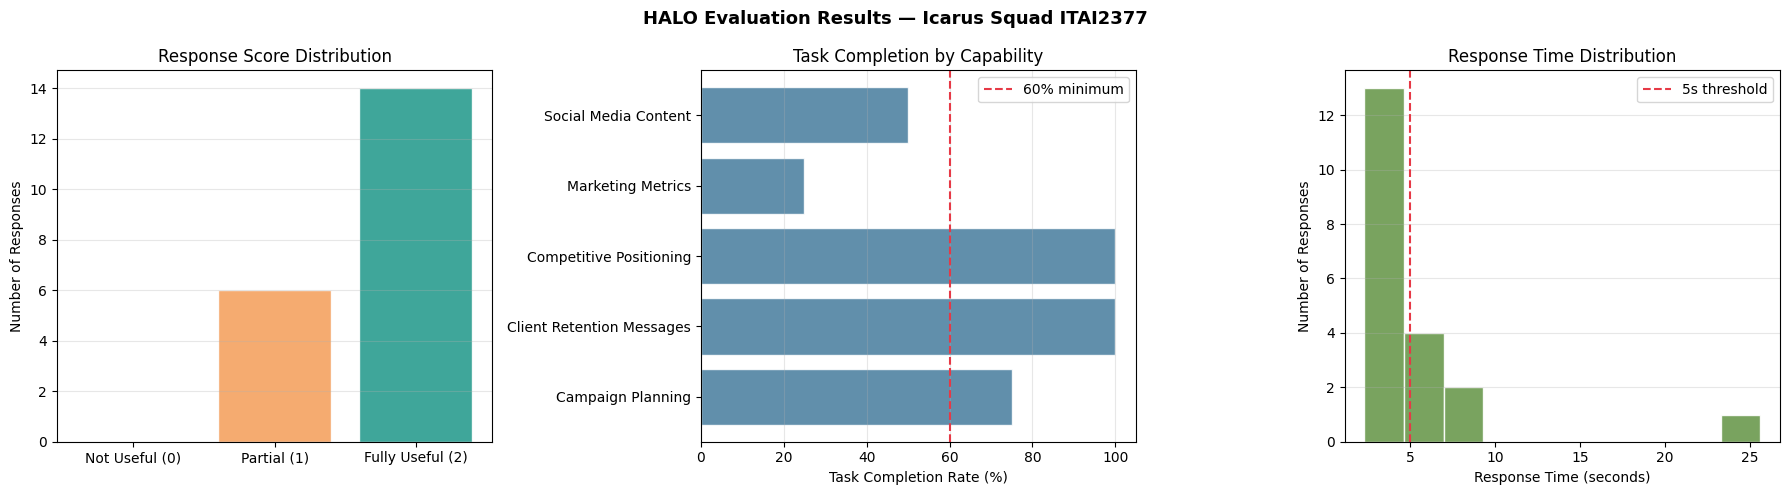


Visualization saved to: /content/drive/MyDrive/HALO_Project/visualizations/evaluation_results.png


In [24]:
# Step 10: Analyze Evaluation Results and Generate Visualizations
eval_csv  = f'{BASE_DIR}/evaluation/halo_eval_results.csv'
df_scored = pd.read_csv(eval_csv)
df_scored['manual_score'] = pd.to_numeric(df_scored['manual_score'], errors='coerce')

if df_scored['manual_score'].isna().all():
    print('Manual scores not yet filled in.')
    print('Open the CSV in Google Sheets, fill in manual_score (0/1/2), then re-run this cell.')
else:
    # Calculate metrics
    total_scored    = df_scored['manual_score'].notna().sum()
    relevant        = (df_scored['manual_score'] >= 1).sum()
    relevance_rate  = relevant / total_scored * 100
    time_compliance = df_scored['under_5s'].mean() * 100

    completion_by_func = df_scored.groupby('functionality').apply(
        lambda g: (g['manual_score'] == 2).sum() / len(g) * 100
    ).round(1)

    avg_score_by_func = df_scored.groupby('functionality')['manual_score'].mean().round(2)

    # Print results
    print('HALO EVALUATION RESULTS')
    print('=' * 60)
    print(f'Questions scored:             {total_scored} / {len(df_scored)}')
    print(f'Overall Relevance Rate:       {relevance_rate:.1f}%  '
          f'[Min 80%] {"PASS" if relevance_rate >= 80 else "NEEDS IMPROVEMENT"}')
    print(f'Response Time Compliance:     {time_compliance:.1f}%  '
          f'[Min 90%] {"PASS" if time_compliance >= 90 else "NEEDS IMPROVEMENT"}')
    print(f'Average Score (0-2 scale):    {df_scored["manual_score"].mean():.2f}')
    print()
    print('Task Completion Rate by Capability (score = 2 only):')
    for func, rate in completion_by_func.items():
        avg  = avg_score_by_func[func]
        status = 'PASS' if rate >= 60 else 'NEEDS IMPROVEMENT'
        print(f'  {func.replace("_"," ").title():<35} {rate:>5.1f}%  avg={avg}  [{status}]')

    # Generate visualizations
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('HALO Evaluation Results — Icarus Squad ITAI2377',
                 fontsize=13, fontweight='bold')

    # Chart 1: Score distribution
    sc = df_scored['manual_score'].value_counts().sort_index()
    axes[0].bar(
        ['Not Useful (0)', 'Partial (1)', 'Fully Useful (2)'],
        [sc.get(0,0), sc.get(1,0), sc.get(2,0)],
        color=['#e63946','#f4a261','#2a9d8f'],
        edgecolor='white', alpha=0.9
    )
    axes[0].set_ylabel('Number of Responses')
    axes[0].set_title('Response Score Distribution')
    axes[0].grid(axis='y', alpha=0.3)

    # Chart 2: Task completion by capability
    funcs = [f.replace('_',' ').title() for f in completion_by_func.index]
    axes[1].barh(funcs, completion_by_func.values,
                 color='#457b9d', alpha=0.85, edgecolor='white')
    axes[1].axvline(x=60, color='#e63946', linestyle='--',
                    linewidth=1.5, label='60% minimum')
    axes[1].set_xlabel('Task Completion Rate (%)')
    axes[1].set_title('Task Completion by Capability')
    axes[1].legend()
    axes[1].grid(axis='x', alpha=0.3)

    # Chart 3: Response time distribution
    axes[2].hist(df_scored['response_time'], bins=10,
                 color='#6a994e', edgecolor='white', alpha=0.9)
    axes[2].axvline(x=5, color='#e63946', linestyle='--',
                    linewidth=1.5, label='5s threshold')
    axes[2].set_xlabel('Response Time (seconds)')
    axes[2].set_ylabel('Number of Responses')
    axes[2].set_title('Response Time Distribution')
    axes[2].legend()
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    viz_path = f'{BASE_DIR}/visualizations/evaluation_results.png'
    plt.savefig(viz_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nVisualization saved to: {viz_path}')

---
## Step 11 — Save All Logs

**Cell explanation:** This cell saves the retrieval log and response log to
CSV files on Google Drive. These logs serve two purposes:

1. **Evidence of testing** — the logs show your team ran systematic tests
   and collected real performance data, which is required by the rubric
2. **Analysis material** — the retrieval log shows which sources were used
   most often and how similarity scores varied across query types, which
   provides concrete data for the reflection and analysis sections of the report

The summary statistics printed at the end give you key numbers to reference
in the report without needing to open and analyze the raw CSV files.

In [19]:
# Step 11: Save All Logs to Drive
# Save retrieval log
if retrieval_log:
    df_retrieval   = pd.DataFrame(retrieval_log)
    retrieval_path = f'{BASE_DIR}/logs/retrieval_log.csv'
    df_retrieval.to_csv(retrieval_path, index=False)
    print(f'Retrieval log saved: {len(df_retrieval)} entries')
    print(f'  Path: {retrieval_path}')
else:
    print('No retrieval events logged yet. Run Steps 7 and 9 first.')

# Save response log
if response_log:
    df_responses  = pd.DataFrame(response_log)
    response_path = f'{BASE_DIR}/logs/response_log.csv'
    df_responses.to_csv(response_path, index=False)
    print(f'\nResponse log saved: {len(df_responses)} entries')
    print(f'  Path: {response_path}')
    print(f'\nResponse Log Summary:')
    print(f'  Total queries logged:        {len(df_responses)}')
    print(f'  Average response time:       {df_responses["response_time_s"].mean():.2f}s')
    print(f'  Average tokens per query:    {df_responses["tokens_used"].mean():.0f}')
    print(f'  Average top similarity:      {df_responses["top_similarity"].mean():.4f}')
    print(f'  Queries under 5s:            {(df_responses["response_time_s"] < 5).mean()*100:.1f}%')
else:
    print('No responses logged yet. Run Steps 7 and 9 first.')

# Save interaction log from halo_chat_with_logging
if os.path.exists(feedback_file):
    df_interactions = pd.read_csv(feedback_file)
    print(f'\nInteraction log: {len(df_interactions)} entries')
    print(f'  Path: {feedback_file}')

Retrieval log saved: 140 entries
  Path: /content/drive/MyDrive/HALO_Project/logs/retrieval_log.csv

Response log saved: 28 entries
  Path: /content/drive/MyDrive/HALO_Project/logs/response_log.csv

Response Log Summary:
  Total queries logged:        28
  Average response time:       4.71s
  Average tokens per query:    164
  Average top similarity:      0.1399
  Queries under 5s:            75.0%

Interaction log: 23 entries
  Path: /content/drive/MyDrive/HALO_Project/logs/halo_interactions.csv


---
## Notebook 2 Complete

| Step | Component | Status |
|---|---|---|
| 1 | Dependencies installed | Run once per session |
| 2 | OpenCode / Gemini APIs connected | Requires API Keys in Secrets |
| 3 | ChromaDB loaded from Drive | Requires Notebook 1 to be complete |
| 4 | Retrieval function with domain filter | Ready |
| 5 | System prompt + response generator | Ready |
| 6 | Full pipeline + logging wrapper | Ready |
| 7 | Representative examples (Multi-model) | Run to test |
| 8 | Frontend interface | See Notebook 3 |
| 9 | 20-question evaluation suite | Generates or loads CSV |
| 9.2 | Interactive Scoring | Run to score responses |
| 10 | Scored results + visualizations | Run after scoring |
| 11 | All logs saved to Drive | Run after Steps 7 and 9 |

### Team Checklist
- [ ] Each member adds `OPENCODE_API_KEY` and `GEMINI_API_KEY` to Colab Secrets
- [ ] Each member adds Drive shortcut to `HALO_Project`
- [ ] Run Steps 1-9 in order after Notebook 1 is complete
- [ ] Run Step 9.2 to interactively score all 20 questions (0, 1, or 2)
- [ ] Run Step 10 to generate final evaluation charts
- [ ] Run Step 11 to save all logs
- [ ] Save visualizations and logs for the report
- [ ] For the chat interface, open and run Notebook 3